In [3]:
import pandas as pd
import numpy as np

train = pd.read_csv("../data/train.csv")

df = train.copy()

df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   id         750000 non-null  int64
 1   age        750000 non-null  int64
 2   job        750000 non-null  str  
 3   marital    750000 non-null  str  
 4   education  750000 non-null  str  
 5   default    750000 non-null  str  
 6   balance    750000 non-null  int64
 7   housing    750000 non-null  str  
 8   loan       750000 non-null  str  
 9   contact    750000 non-null  str  
 10  day        750000 non-null  int64
 11  month      750000 non-null  str  
 12  duration   750000 non-null  int64
 13  campaign   750000 non-null  int64
 14  pdays      750000 non-null  int64
 15  previous   750000 non-null  int64
 16  poutcome   750000 non-null  str  
 17  y          750000 non-null  int64
dtypes: int64(9), str(9)
memory usage: 103.0 MB


In [5]:
df.isna().sum().sum()

np.int64(0)

In [6]:
df.columns.tolist()

['id',
 'age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

In [7]:
df.nunique().sort_values()

housing           2
default           2
loan              2
y                 2
contact           3
marital           3
poutcome          4
education         4
job              12
month            12
day              31
previous         50
campaign         52
age              78
pdays           596
duration       1760
balance        8217
id           750000
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,750000.0,374999.500000,216506.495284,0.0,187499.75,374999.5,562499.25,749999.0
age,750000.0,40.926395,10.098829,18.0,33.00,39.0,48.00,95.0
balance,750000.0,1204.067397,2836.096759,-8019.0,0.00,634.0,1390.00,99717.0
day,750000.0,16.117209,8.250832,1.0,9.00,17.0,21.00,31.0
duration,750000.0,256.229144,272.555662,1.0,91.00,133.0,361.00,4918.0
campaign,750000.0,2.577008,2.718514,1.0,1.00,2.0,3.00,63.0
pdays,750000.0,22.412733,77.319998,-1.0,-1.00,-1.0,-1.00,871.0
previous,750000.0,0.298545,1.335926,0.0,0.00,0.0,0.00,200.0
y,750000.0,0.120651,0.325721,0.0,0.00,0.0,0.00,1.0


In [9]:
df.describe(include="object").T

C:\Users\otton\AppData\Local\Temp\ipykernel_13168\1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
job,750000,12,management,175541
marital,750000,3,married,480759
education,750000,4,secondary,401683
default,750000,2,no,737151
housing,750000,2,yes,411288
loan,750000,2,no,645023
contact,750000,3,cellular,486655
month,750000,12,may,228411
poutcome,750000,4,unknown,672450


In [10]:
df = df.drop(columns=["id"])

print("Filas:", len(df))
print("Columnas:", len(df.columns))
print(df.columns.tolist())

Filas: 750000
Columnas: 17
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [11]:
X = df.drop(columns=["y"])
y = df["y"]

In [12]:
X = df.drop(columns=["y"])
y = df["y"]

print("X:", X.shape)
print("y:", y.shape)

X: (750000, 16)
y: (750000,)


In [13]:
print(y.value_counts())
print()
print(y.value_counts(normalize=True) * 100)

y
0    659512
1     90488
Name: count, dtype: int64

y
0    87.934933
1    12.065067
Name: proportion, dtype: float64


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (600000, 16)
X_test: (150000, 16)
y_train: (600000,)
y_test: (150000,)


In [16]:
print("Train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest:")
print(y_test.value_counts(normalize=True) * 100)

Train:
y
0    87.935
1    12.065
Name: proportion, dtype: float64

Test:
y
0    87.934667
1    12.065333
Name: proportion, dtype: float64


In [17]:
numeric_features = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [20]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','job','marital',...,'pdays','previous','poutcome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining colu

In [21]:
y_pred = logistic_model.predict(X_test)

In [22]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [23]:
print(y_pred.shape)
print(y_prob.shape)

(150000,)
(150000,)


In [24]:
print(y_pred[:10])
print(y_prob[:10])

[0 0 0 0 1 0 0 0 1 0]
[0.00230391 0.00848771 0.28261325 0.09128008 0.66150978 0.0078367
 0.01189251 0.02620384 0.59662873 0.01133717]


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9150333333333334
Precision: 0.7084663914635096
Recall: 0.5025969720411095
F1: 0.5880337459999353
ROC-AUC: 0.9424174646725628


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[128159   3743]
 [  9002   9096]]


In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=12,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','job','marital',...,'pdays','previous','poutcome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining colu

In [28]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print(rf_pred.shape)
print(rf_prob.shape)

(150000,)
(150000,)


In [29]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.9216533333333333
Precision: 0.7986071899115378
Recall: 0.46889159023096477
F1: 0.5908647820637795
ROC-AUC: 0.9569217839254199


In [30]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.915033,0.708466,0.502597,0.588034,0.942417
1,Random Forest,0.921653,0.798607,0.468892,0.590865,0.956922


In [31]:
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

for threshold in thresholds:
    rf_pred_threshold = (rf_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Precision:", precision_score(y_test, rf_pred_threshold))
    print("Recall:", recall_score(y_test, rf_pred_threshold))
    print("F1:", f1_score(y_test, rf_pred_threshold))


Threshold: 0.2
Precision: 0.5330176093916755
Recall: 0.8830810034257929
F1: 0.6647809991264922

Threshold: 0.3
Precision: 0.6185207508179783
Recall: 0.7938446237153277
F1: 0.695300779170498

Threshold: 0.4
Precision: 0.7272442326980942
Recall: 0.6410100563598188
F1: 0.6814096916299559

Threshold: 0.5
Precision: 0.7986071899115378
Recall: 0.46889159023096477
F1: 0.5908647820637795

Threshold: 0.6
Precision: 0.8591549295774648
Recall: 0.26627251630014365
F1: 0.40654658961488166

Threshold: 0.7
Precision: 0.9036431733060947
Recall: 0.1466460382362692
F1: 0.2523413358687901


In [32]:
rf_pred_03 = (rf_prob >= 0.30).astype(int)

cm_rf_03 = confusion_matrix(y_test, rf_pred_03)

print(cm_rf_03)

[[123041   8861]
 [  3731  14367]]


In [33]:
features_no_duration = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "balance",
    "housing",
    "loan",
    "contact",
    "day",
    "month",
    "campaign",
    "pdays",
    "previous",
    "poutcome"
]

X_train_no_duration = X_train[features_no_duration]
X_test_no_duration = X_test[features_no_duration]

print(X_train_no_duration.shape)
print(X_test_no_duration.shape)

numeric_features_no_duration = [
    "age",
    "balance",
    "day",
    "campaign",
    "pdays",
    "previous"
]

categorical_features_no_duration = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

preprocessor_no_duration = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_no_duration),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_no_duration)
    ]
)

rf_no_duration = Pipeline(
    steps=[
        ("preprocessor", preprocessor_no_duration),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=12,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_no_duration.fit(
    X_train_no_duration,
    y_train
)

(600000, 15)
(150000, 15)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['age','job','marital',...,'pdays','previous','poutcome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining colu

In [34]:
rf_no_duration_pred = rf_no_duration.predict(X_test_no_duration)

rf_no_duration_prob = rf_no_duration.predict_proba(
    X_test_no_duration
)[:, 1]

print("rf_no_duration_pred y prob shape")
print(rf_no_duration_pred.shape)
print(rf_no_duration_prob.shape)

print("rf_no_duration_pred y prob :10")

print(rf_no_duration_pred[:10])
print(rf_no_duration_prob[:10])

rf_no_duration_pred y prob shape
(150000,)
(150000,)
rf_no_duration_pred y prob :10
[0 0 0 0 0 0 0 0 0 0]
[0.01531177 0.05070716 0.04558403 0.06943775 0.18144916 0.09807225
 0.02685826 0.11925511 0.15794434 0.08169059]


In [35]:
print("Accuracy:", accuracy_score(y_test, rf_no_duration_pred))
print("Precision:", precision_score(y_test, rf_no_duration_pred))
print("Recall:", recall_score(y_test, rf_no_duration_pred))
print("F1:", f1_score(y_test, rf_no_duration_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_no_duration_prob))

Accuracy: 0.89354
Precision: 0.7424276930084264
Recall: 0.18013040114929826
F1: 0.2899195162079239
ROC-AUC: 0.8268569357943254


In [36]:
thresholds_no_duration = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

for threshold in thresholds_no_duration:
    pred = (rf_no_duration_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Precision:", precision_score(y_test, pred))
    print("Recall:", recall_score(y_test, pred))
    print("F1:", f1_score(y_test, pred))


Threshold: 0.1
Precision: 0.2522747672433517
Recall: 0.7920212178141232
F1: 0.3826634809188836

Threshold: 0.15
Precision: 0.35649139988982065
Recall: 0.6436070284009283
F1: 0.45883557866540614

Threshold: 0.2
Precision: 0.45314171433886796
Recall: 0.5383467786495746
F1: 0.4920831334124599

Threshold: 0.25
Precision: 0.5232407806439697
Recall: 0.4696099016465908
F1: 0.4949768498296497

Threshold: 0.3
Precision: 0.5783720930232558
Recall: 0.41225549784506577
F1: 0.4813858958642493

Threshold: 0.4
Precision: 0.6499760421657882
Recall: 0.29981213393745165
F1: 0.41034560992210545

Threshold: 0.5
Precision: 0.7424276930084264
Recall: 0.18013040114929826
F1: 0.2899195162079239


In [37]:
rf_model_final = rf_no_duration.named_steps["model"]
importances = rf_model_final.feature_importances_

feature_names = rf_no_duration.named_steps[
    "preprocessor"
].get_feature_names_out()

print(len(importances))
print(len(feature_names))

50
50


In [38]:
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
48,cat__poutcome_success,0.221699
1,num__balance,0.127759
0,num__age,0.065512
4,num__pdays,0.063203
28,cat__housing_yes,0.054947
27,cat__housing_no,0.042746
33,cat__contact_unknown,0.037803
31,cat__contact_cellular,0.032606
34,cat__month_apr,0.029736
41,cat__month_mar,0.028625


In [39]:
feature_importance["original_feature"] = (
    feature_importance["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.split("_")
    .str[0]
)

grouped_importance = (
    feature_importance
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

grouped_importance

original_feature
poutcome     0.276796
month        0.158299
balance      0.127759
housing      0.097693
contact      0.072718
age          0.065512
pdays        0.063203
previous     0.027795
day          0.027137
campaign     0.023139
marital      0.019254
job          0.016980
loan         0.016343
education    0.007131
default      0.000241
Name: importance, dtype: float64

In [40]:
df.groupby("poutcome")["y"].mean().sort_values(ascending=False)

poutcome
success    0.764004
other      0.166848
failure    0.132794
unknown    0.101898
Name: y, dtype: float64

In [41]:
df["poutcome"].value_counts()

df["poutcome"].value_counts(normalize=True) * 100



poutcome
unknown    89.660000
failure     6.015333
success     2.358800
other       1.965867
Name: proportion, dtype: float64

In [42]:
df.groupby("month")["y"].mean().sort_values(ascending=False)
df.groupby("month")["y"].size().sort_values(ascending=False)

month
may    228411
aug    128859
jul    110647
jun     93670
nov     66062
apr     41319
feb     37611
jan     18937
oct      9204
sep      7409
mar      5802
dec      2069
Name: y, dtype: int64

In [43]:
df.groupby("month")["y"].mean().sort_values(ascending=False)

month
mar    0.571355
sep    0.534755
dec    0.513291
oct    0.490004
apr    0.235654
feb    0.206801
jan    0.124148
aug    0.112161
nov    0.109806
jun    0.103726
jul    0.090847
may    0.071354
Name: y, dtype: float64

In [44]:
month_poutcome = pd.crosstab(
    df["month"],
    df["poutcome"],
    values=df["y"],
    aggfunc="mean"
)

month_poutcome

poutcome,failure,other,success,unknown
month,,,,
apr,0.119082,0.146948,0.775144,0.237985
aug,0.321429,0.425325,0.749602,0.094711
dec,0.329317,0.505747,0.746479,0.453438
feb,0.130047,0.109611,0.796411,0.188926
jan,0.079591,0.108858,0.727545,0.105019
jul,0.379562,0.445693,0.830827,0.080907
jun,0.340498,0.439080,0.773946,0.090218
mar,0.418838,0.467337,0.836469,0.551779
may,0.085533,0.088534,0.693902,0.062004


In [45]:
df["balance_group"] = pd.cut(
    df["balance"],
    bins=[-np.inf, 0, 500, 1000, 1500, np.inf],
    labels=["Negativo", "1-500", "501-1000", "1001-1500", "1500+"]
)

df["balance_group"].value_counts()

df.groupby("balance_group", observed=True)["y"].mean().sort_values(ascending=False)

balance_group
1500+        0.211692
1001-1500    0.139952
501-1000     0.131880
1-500        0.099069
Negativo     0.035272
Name: y, dtype: float64

In [46]:
df["balance_group"].value_counts()

balance_group
Negativo     197804
501-1000     182560
1500+        172241
1-500        113809
1001-1500     83586
Name: count, dtype: int64

In [47]:
df.groupby("housing")["y"].mean()

housing
no     0.175778
yes    0.075251
Name: y, dtype: float64

In [48]:
df["housing"].value_counts()

housing
yes    411288
no     338712
Name: count, dtype: int64

In [49]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 29, 39, 49, 59, 69, 100],
    labels=["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]
)

In [50]:
df.groupby("age_group", observed=True)["y"].mean()

age_group
18-29    0.203802
30-39    0.111254
40-49    0.091623
50-59    0.094199
60-69    0.342873
70+      0.519364
Name: y, dtype: float64

In [51]:
df["age_group"].value_counts().sort_index()

age_group
18-29     74425
30-39    311404
40-49    198509
50-59    142093
60-69     17785
70+        5784
Name: count, dtype: int64

In [52]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y',
 'balance_group',
 'age_group']

In [53]:
X = df.drop(columns=["y"])
y = df["y"]

In [54]:
X = X.drop(columns=["balance_group", "age_group"])

In [55]:
X.shape

(750000, 16)

In [56]:
X = df.drop(
    columns=["y", "duration", "balance_group", "age_group"]
)

y = df["y"]

In [57]:
print("X:", X.shape)
print("y:", y.shape)

X: (750000, 15)
y: (750000,)


In [58]:
X.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'campaign',
 'pdays',
 'previous',
 'poutcome']

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (600000, 15)
X_test: (150000, 15)
y_train: (600000,)
y_test: (150000,)


In [60]:
print("Train:")
print(y_train.value_counts(normalize=True).mul(100).round(3))

print("\nTest:")
print(y_test.value_counts(normalize=True).mul(100).round(3))

Train:
y
0    87.935
1    12.065
Name: proportion, dtype: float64

Test:
y
0    87.935
1    12.065
Name: proportion, dtype: float64


In [61]:
numeric_features = [
    "age",
    "balance",
    "day",
    "campaign",
    "pdays",
    "previous"
]

categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

print("Numéricas:", len(numeric_features))
print("Categóricas:", len(categorical_features))
print("Total:", len(numeric_features) + len(categorical_features))

Numéricas: 6
Categóricas: 9
Total: 15


In [62]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [63]:
preprocessor.fit(X_train)

X_train_transformed = preprocessor.transform(X_train)

print(X_train_transformed.shape)

(600000, 50)


In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [65]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['age','job','marital',...,'pdays','previous','poutcome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining

In [66]:
rf_pred = rf_model.predict(X_test)

In [67]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [68]:
print("rf_pred shape:", rf_pred.shape)
print("rf_prob shape:", rf_prob.shape)

rf_pred shape: (150000,)
rf_prob shape: (150000,)


In [69]:
print(rf_pred[:10])
print(rf_prob[:10])

[0 0 0 0 0 0 0 0 0 0]
[0.   0.   0.13 0.07 0.36 0.06 0.   0.04 0.26 0.03]


In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.8929466666666667
Precision: 0.6057871810827629
Recall: 0.3227428445132059
F1: 0.4211247296322999
ROC-AUC: 0.8140347549274985


In [71]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, rf_pred)

print(cm_rf)

[[128101   3801]
 [ 12257   5841]]


In [72]:
for threshold in [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]:

    rf_threshold_pred = (rf_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Precision:", precision_score(y_test, rf_threshold_pred))
    print("Recall:", recall_score(y_test, rf_threshold_pred))
    print("F1:", f1_score(y_test, rf_threshold_pred))


Threshold: 0.1
Precision: 0.2691585424324756


Recall: 0.744446900209968
F1: 0.3953693106787569

Threshold: 0.15
Precision: 0.323685828055266
Recall: 0.6692452204663498
F1: 0.4363348163625556

Threshold: 0.2
Precision: 0.37059517787894114
Recall: 0.607249419825395
F1: 0.4602852176826587

Threshold: 0.25
Precision: 0.4125494071146245
Recall: 0.553652337274837
F1: 0.4727976218562733

Threshold: 0.3
Precision: 0.4531451213472016
Recall: 0.5055254724278926
F1: 0.47790430422064356

Threshold: 0.4
Precision: 0.528140350877193
Recall: 0.41584705492319596
F1: 0.4653147026091258

Threshold: 0.5
Precision: 0.5993198639727946
Recall: 0.3310863078793237
F1: 0.4265375854214123


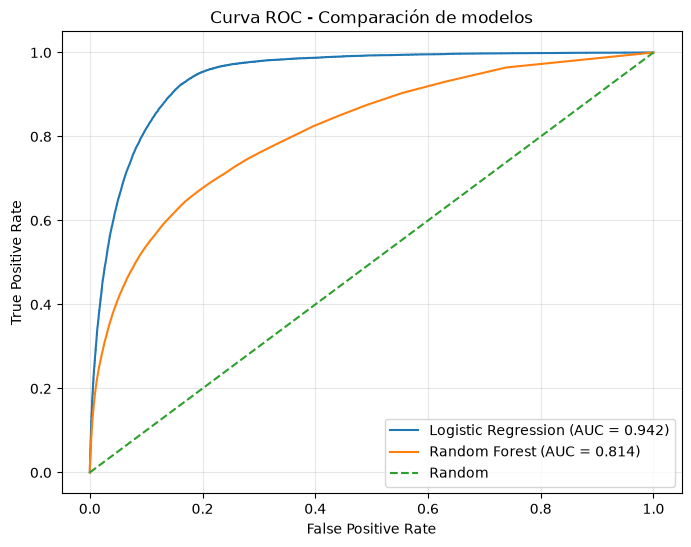

In [73]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Comparación de modelos")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


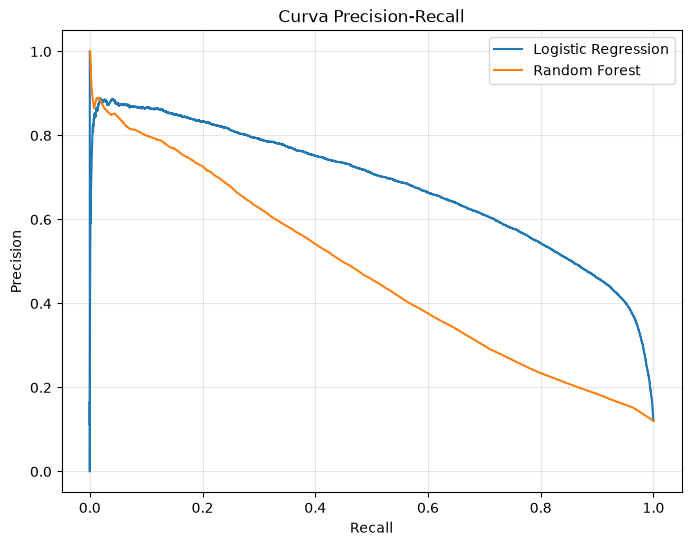

In [74]:
from sklearn.metrics import precision_recall_curve
precision_log, recall_log, _ = precision_recall_curve(
    y_test,
    y_prob
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    rf_prob
)
plt.figure(figsize=(8, 6))

plt.plot(
    recall_log,
    precision_log,
    label="Logistic Regression"
)

plt.plot(
    recall_rf,
    precision_rf,
    label="Random Forest"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [75]:
thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6]

for threshold in thresholds:

    pred = (y_prob >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_test, pred):.3f} | "
        f"Recall: {recall_score(y_test, pred):.3f} | "
        f"F1: {f1_score(y_test, pred):.3f}"
    )

Threshold: 0.10 | Precision: 0.454 | Recall: 0.908 | F1: 0.606
Threshold: 0.15 | Precision: 0.505 | Recall: 0.848 | F1: 0.633
Threshold: 0.20 | Precision: 0.548 | Recall: 0.795 | F1: 0.649
Threshold: 0.25 | Precision: 0.585 | Recall: 0.739 | F1: 0.653
Threshold: 0.30 | Precision: 0.617 | Recall: 0.689 | F1: 0.651
Threshold: 0.35 | Precision: 0.645 | Recall: 0.639 | F1: 0.642
Threshold: 0.40 | Precision: 0.667 | Recall: 0.595 | F1: 0.629
Threshold: 0.50 | Precision: 0.708 | Recall: 0.503 | F1: 0.588
Threshold: 0.60 | Precision: 0.744 | Recall: 0.420 | F1: 0.537


In [76]:
logistic_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','job','marital',...,'pdays','previous','poutcome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining colu

In [77]:
print(numeric_features)
print(categorical_features)

['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [78]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_final = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [79]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model_final = Pipeline(
    steps=[
        ("preprocessor", preprocessor_final),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

logistic_model_final.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['age','job','marital',...,'pdays','previous','poutcome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining

In [80]:
y_pred_final = logistic_model_final.predict(X_test)

y_prob_final = logistic_model_final.predict_proba(X_test)[:, 1]

print(y_pred_final.shape)
print(y_prob_final.shape)

print(y_pred_final[:10])
print(y_prob_final[:10])

(150000,)
(150000,)
[0 0 0 0 0 0 0 0 0 0]
[0.02128819 0.02592209 0.0803136  0.0974767  0.15216999 0.06431985
 0.04361985 0.13977692 0.13166458 0.06543138]


In [81]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1:", f1_score(y_test, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_final))

print("confusion_matrix")
print(confusion_matrix(y_test, y_pred_final))

Accuracy: 0.8918066666666666
Precision: 0.6839929119905493
Recall: 0.1919549121449884
F1: 0.2997799542650041
ROC-AUC: 0.7779967597143735
confusion_matrix
[[130297   1605]
 [ 14624   3474]]


In [82]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

for threshold in thresholds:

    pred = (y_prob_final >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_test, pred):.3f} | "
        f"Recall: {recall_score(y_test, pred):.3f} | "
        f"F1: {f1_score(y_test, pred):.3f}"
    )

Threshold: 0.10 | Precision: 0.226 | Recall: 0.742 | F1: 0.347
Threshold: 0.15 | Precision: 0.341 | Recall: 0.578 | F1: 0.429
Threshold: 0.20 | Precision: 0.455 | Recall: 0.469 | F1: 0.462
Threshold: 0.25 | Precision: 0.527 | Recall: 0.401 | F1: 0.455
Threshold: 0.30 | Precision: 0.576 | Recall: 0.349 | F1: 0.435
Threshold: 0.35 | Precision: 0.612 | Recall: 0.298 | F1: 0.401
Threshold: 0.40 | Precision: 0.635 | Recall: 0.256 | F1: 0.365
Threshold: 0.50 | Precision: 0.684 | Recall: 0.192 | F1: 0.300


In [83]:
powerbi_df = X_test.copy()

powerbi_df["y"] = y_test

powerbi_df["probabilidad_aceptacion"] = y_prob_final

powerbi_df["prediccion"] = (
    powerbi_df["probabilidad_aceptacion"] >= 0.20
).astype(int)

powerbi_df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y,probabilidad_aceptacion,prediccion
619475,31,blue-collar,single,secondary,no,18,yes,yes,unknown,5,may,1,-1,0,unknown,0,0.021288,0
711174,29,blue-collar,married,secondary,no,1599,yes,no,unknown,28,may,1,-1,0,unknown,0,0.025922,0
286723,36,blue-collar,married,secondary,no,47,yes,no,cellular,11,may,4,-1,0,unknown,0,0.080314,0
545380,44,self-employed,married,tertiary,no,1930,no,no,unknown,11,jun,1,-1,0,unknown,0,0.097477,0
676916,50,management,married,tertiary,no,5041,no,no,cellular,14,aug,2,-1,0,unknown,0,0.152170,0


In [84]:
print(powerbi_df.shape)
print(powerbi_df.columns.tolist())

(150000, 18)
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'y', 'probabilidad_aceptacion', 'prediccion']


In [85]:
import numpy as np

powerbi_df["segmento_propension"] = np.select(
    [
        powerbi_df["probabilidad_aceptacion"] < 0.10,
        powerbi_df["probabilidad_aceptacion"] < 0.20,
        powerbi_df["probabilidad_aceptacion"] >= 0.20
    ],
    [
        "Baja",
        "Media",
        "Alta"
    ],
    default="Baja"
)


powerbi_df["segmento_propension"].value_counts()

powerbi_df["segmento_propension"].value_counts(normalize=True) * 100

segmento_propension
Baja     60.433333
Media    27.128000
Alta     12.438667
Name: proportion, dtype: float64

In [86]:
powerbi_df.groupby("segmento_propension")["y"].agg(
    ["count", "mean"]
).sort_values("mean", ascending=False)

,count,mean
segmento_propension,,
Alta,18658,0.455301
Media,40692,0.121375
Baja,90650,0.051451


In [87]:
powerbi_df.to_csv(
    "clientes_powerbi.csv",
    index=False
)

In [90]:
powerbi_df = X_test.copy()

powerbi_df["y"] = y_test
powerbi_df["probabilidad_aceptacion"] = y_prob_final

powerbi_df["prediccion"] = (
    powerbi_df["probabilidad_aceptacion"] >= 0.20
).astype(int)

powerbi_df["segmento_propension"] = pd.cut(
    powerbi_df["probabilidad_aceptacion"],
    bins=[-np.inf, 0.10, 0.20, np.inf],
    labels=["Baja", "Media", "Alta"],
    right=False
)

# Variables adicionales para análisis en Power BI
powerbi_df["balance_group"] = pd.cut(
    powerbi_df["balance"],
    bins=[-np.inf, 0, 500, 1000, 1500, np.inf],
    labels=["Negativo", "1-500", "501-1000", "1001-1500", "1500+"]
)

powerbi_df["age_group"] = pd.cut(
    powerbi_df["age"],
    bins=[17, 29, 39, 49, 59, 69, 100],
    labels=["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]
)

powerbi_df["duration"] = df.loc[powerbi_df.index, "duration"]

powerbi_df.to_csv(
    "../data/clientes_powerbi.csv",
    index=False
)

print(powerbi_df.shape)
print(powerbi_df.columns.tolist())

(150000, 22)
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'y', 'probabilidad_aceptacion', 'prediccion', 'segmento_propension', 'balance_group', 'age_group', 'duration']
